Celda 1: Librerías y Configuración

In [13]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, classification_report
import os

# Configurar el dispositivo (GPU o CPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Trabajando en: {device}")

Trabajando en: cpu


Celda 2: Clase Dataset con Imputación (Promedios)
Aquí aplicamos lo que pidió tu ingeniero: en lugar de dropna(), usamos SimpleImputer.

Para números: Rellenamos con la media (promedio).

Para categorías: Rellenamos con la moda (el valor más frecuente).

In [8]:
class DatasetParcial(Dataset):
    def __init__(self, file_path):
        # 1. Cargar reconociendo el "?" como nulo
        df = pd.read_csv(file_path, header=None, na_values="?", skipinitialspace=True)
        
        # Identificar columnas por tipo
        cols_num = df.select_dtypes(include=[np.number]).columns
        cols_cat = df.select_dtypes(exclude=[np.number]).columns

        # 2. IMPUTACIÓN (No eliminamos, rellenamos con el promedio)
        # Para números: Media
        imp_num = SimpleImputer(strategy='mean')
        if len(cols_num) > 0:
            df[cols_num] = imp_num.fit_transform(df[cols_num])
            
        # Para categorías: Moda (Most Frequent)
        imp_cat = SimpleImputer(strategy='most_frequent')
        if len(cols_cat) > 0:
            df[cols_cat] = imp_cat.fit_transform(df[cols_cat])

        # 3. LABEL ENCODER (Palabras a números)
        self.encoders = {}
        for col in cols_cat:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            self.encoders[col] = le

        # 4. SEPARACIÓN Y ESCALADO (StandardScaler)
        # X: todas menos la última | Y: la última columna
        x_raw = df.iloc[:, :-1].values.astype(np.float32)
        y_raw = df.iloc[:, -1].values.astype(np.int64)

        self.scaler = StandardScaler()
        self.X = torch.from_numpy(self.scaler.fit_transform(x_raw))
        self.y = torch.from_numpy(y_raw)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

Celda 3: Definición de la Red Neuronal

In [9]:
class RedNeuronales(nn.Module):
    def __init__(self, input_size, num_classes):
        super(RedNeuronales, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.layers(x)

Celda 4: Carga de Datos con TU RUTA y Gráfico de Balanceo

<>:26: SyntaxWarning: invalid escape sequence '\d'
<>:26: SyntaxWarning: invalid escape sequence '\d'
C:\Users\villa\AppData\Local\Temp\ipykernel_26032\2424966080.py:26: SyntaxWarning: invalid escape sequence '\d'
  print("ÚLTIMO RECURSO: Mueve la carpeta 'datos' al disco C: y cambia la ruta arriba a C:\datos\adult.data")


✅ ¡POR FIN! Cargado desde la ruta de emergencia.


C:\Users\villa\AppData\Local\Temp\ipykernel_26032\2424966080.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=clases, y=conteos, palette='viridis')


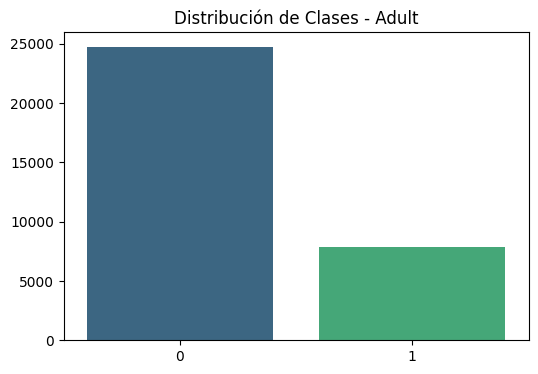

In [10]:
import os
import pandas as pd

# Ruta ultra simplificada (Cámbiala a esta despues de mover los archivos)
ruta_emergencia = r"C:\datos\adult.data"

if os.path.exists(ruta_emergencia):
    try:
        ds = DatasetParcial(ruta_emergencia)
        print("✅ ¡POR FIN! Cargado desde la ruta de emergencia.")
        
        # Gráfico de balanceo rápido
        import numpy as np
        import matplotlib.pyplot as plt
        import seaborn as sns
        y_val = ds.y.numpy()
        clases, conteos = np.unique(y_val, return_counts=True)
        plt.figure(figsize=(6, 4))
        sns.barplot(x=clases, y=conteos, palette='viridis')
        plt.title('Distribución de Clases - Adult')
        plt.show()
    except Exception as e:
        print(f"❌ El archivo existe pero el código falló: {e}")
else:
    print(f"❌ Python sigue sin ver el archivo en: {ruta_emergencia}")
    print("ÚLTIMO RECURSO: Mueve la carpeta 'datos' al disco C: y cambia la ruta arriba a C:\datos\adult.data")

Celda 5: Entrenamiento con Balanceo de Pesos

In [11]:
# Configurar DataLoader
train_loader = DataLoader(ds, batch_size=64, shuffle=True)

# Cálculo de pesos para que la red no ignore la clase minoritaria
pesos = len(ds.y) / (len(clases) * conteos)
pesos_tensor = torch.FloatTensor(pesos).to(device)

# Inicializar modelo
model = RedNeuronales(ds.X.shape[1], len(clases)).to(device)
criterion = nn.CrossEntropyLoss(weight=pesos_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Entrenamiento
for epoch in range(20):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/20] completada.")

Epoch [5/20] completada.
Epoch [10/20] completada.
Epoch [15/20] completada.
Epoch [20/20] completada.


Celda 6: Matriz de Confusión y Guardado

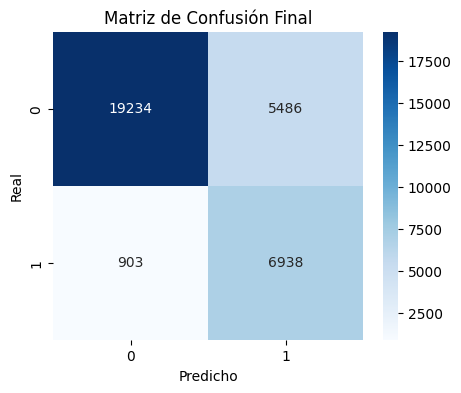

Modelo guardado como 'modelo_parcial.pth'


In [12]:
model.eval()
with torch.no_grad():
    outputs = model(ds.X.to(device))
    _, predicted = torch.max(outputs, 1)
    y_pred = predicted.cpu().numpy()

# Matriz de Confusión
cm = confusion_matrix(ds.y.numpy(), y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión Final')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

# Guardar el modelo
torch.save(model.state_dict(), "modelo_parcial.pth")
print("Modelo guardado como 'modelo_parcial.pth'")